# Demo: Controlled Pendulum
## Verification Master Pendulum within System

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from docs.plot_setup import set_professional_style
plt = set_professional_style()

**Generate FMUComponents**

In [6]:
from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent

demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=True)

fmu_paths

################################################################################
Processing model: ControlledPendulum.AngleEncoder

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


FMU for ControlledPendulum.AngleEncoder moved to:
/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu

################################################################################
Processing model: ControlledPendulum.ControlUnit

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


FMU for ControlledPendulum.ControlUnit moved to:
/ho

{'AngleEncoder': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu'),
 'ControlUnit': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/ControlUnit.fmu'),
 'Demo_Driven': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven.fmu'),
 'Demo_DrivenWithWall': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_DrivenWithWall.fmu'),
 'Demo_Driven_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven_Coupled.fmu'),
 'Drive': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive.fmu'),
 'Drive_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_Coupled.fmu'),
 'Drive_QStat': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_QStat.fmu'),
 'ImpactWall': PosixPath('/home/flo/co

In [223]:
ref          = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Input')
sensor_ref   = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive        = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
eqb_pendulum = FMUComponent(name='pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')
pendulum_wall= FMUComponent(name='pendulum_wall', fmu_path=fmu_paths['PendulumWithWall'], group='Plant')

In [224]:
fmu_list = [ref, sensor_ref, sensor_state, pid, drive, eqb_pendulum]
for fmu in fmu_list:
    print(fmu.name)
    print(" Direct Feedthrough:")
    for output, inputs in fmu.direct_feedthrough.items():
        print(f"  Output: {output} <- Inputs: {inputs}")
    print()

ref
 Direct Feedthrough:
  Output: q_ref <- Inputs: []

sensor_ref
 Direct Feedthrough:
  Output: U_q <- Inputs: ['q']

sensor_state
 Direct Feedthrough:
  Output: U_q <- Inputs: ['q']

pid
 Direct Feedthrough:
  Output: u <- Inputs: ['ref', 'y']

drive
 Direct Feedthrough:
  Output: torque <- Inputs: []

pendulum
 Direct Feedthrough:
  Output: alpha <- Inputs: ['torque']
  Output: omega <- Inputs: []
  Output: q <- Inputs: []



In [225]:
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum

# OpenSim Pendulum
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

# FEM Pendulum with master configuration
fem_pendulum = FEMPendulum(name="FEM_Pendulum", group="Plant")
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3  # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 2700  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 4
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_pendulum.set_parameters(
    mat_params=mat_params,
    contact_params=contact_params,
    init_params=init_params,
    sim_params=sim_params,
    anim_params=anim_params,
    mesh_params=mesh_params
)

pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

#pendulum = pendulum_wall
#pendulum = fem_pendulum

t = 0.0
dt = fem_pendulum.sim_params.tau
t_end = fem_pendulum.sim_params.t_end

**Define Connections**

In [226]:
from SysSimX.system.connection import Connection

c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

**Define System**

In [227]:
from SysSimX.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

# Adding the same connection again to test validation
try:
    system.add_connection(c1)
except ValueError as e:
    print(f"Error: {e}")
system.compute_execution_order()

Error: Duplicate connection: ref.q_ref -> sensor_ref.q


In [228]:
system.execution_order

[['Pendulum', 'ref'], ['sensor_ref', 'sensor_state'], ['pid'], ['drive']]

**Create System Graph**

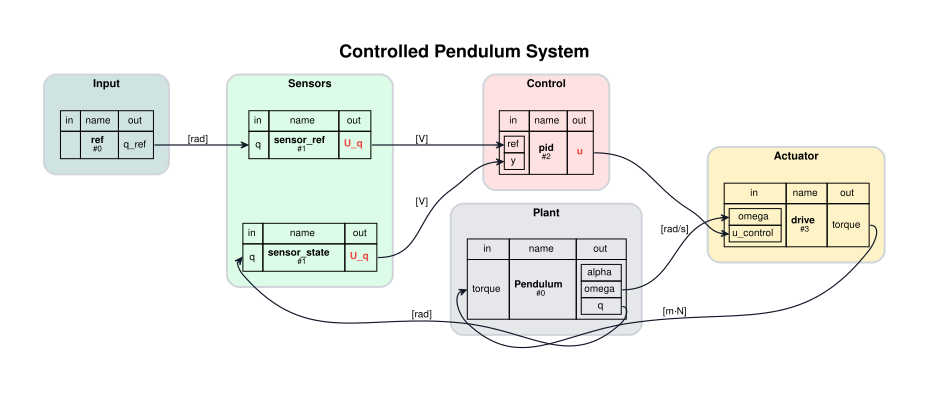

In [229]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("figures/demo-2-8_syssimx_system_graph.svg")

**Setup Simulation Monitor**

In [230]:
pid.set_parameters(Ti=0.01, Td=0.75, k=10)
ref.set_parameters(frequency=1/3)

system.initialize(t, t_end=t_end)

if hasattr(pendulum, 'setup_monitoring'):
    pendulum.setup_monitoring()
if hasattr(pendulum, 'display_monitoring'):
    pendulum.display_monitoring()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [231]:
system.run(t, t_end, dt)

[Pendulum] Switching: EQB to OpenSim @ t=1.0900s
[Pendulum] Switching: OpenSim to FEM @ t=1.3800s
[Pendulum] Switching: FEM to OpenSim @ t=3.2200s
[Pendulum] Switching: OpenSim to EQB @ t=3.3900s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear conver

In [232]:
ref_hist = ref.get_history()
t_vals_ref = ref_hist[ 'q_ref']['time']
q_vals_ref = ref_hist['q_ref']['values']

if isinstance(pendulum, MasterPendulum):
    res_eqb = pendulum.models['EQB'].get_history()
    res_fem = pendulum.models['FEM'].get_history()
    res_os  = pendulum.models['OpenSim'].get_history()

    t_vals_eqb = res_eqb['q']['time']
    q_vals_eqb = res_eqb['q']['values']
    omega_vals_eqb = res_eqb['omega']['values']
    alpha_vals_eqb = res_eqb['alpha']['values']

    t_vals_fem = res_fem['q']['time']
    q_vals_fem = res_fem['q']['values']
    omega_vals_fem = res_fem['omega']['values']
    alpha_vals_fem = res_fem['alpha']['values']
    
    t_vals_os  = res_os['q']['time']
    q_vals_os  = res_os['q']['values']
    omega_vals_os = res_os['omega']['values']
    alpha_vals_os = res_os['alpha']['values']

if isinstance(pendulum, FMUComponent):
    pendulum_hist = pendulum.get_history()
    t_vals_eqb = pendulum_hist['q']['time']
    q_vals_eqb = pendulum_hist['q']['values']
    omega_vals_eqb = pendulum_hist['omega']['values']
    alpha_vals_eqb = pendulum_hist['alpha']['values']
    
# Drive torque
drive_hist = drive.get_history()
t_drive = drive_hist['torque']['time']
torque_drive_vals = drive_hist['torque']['values']



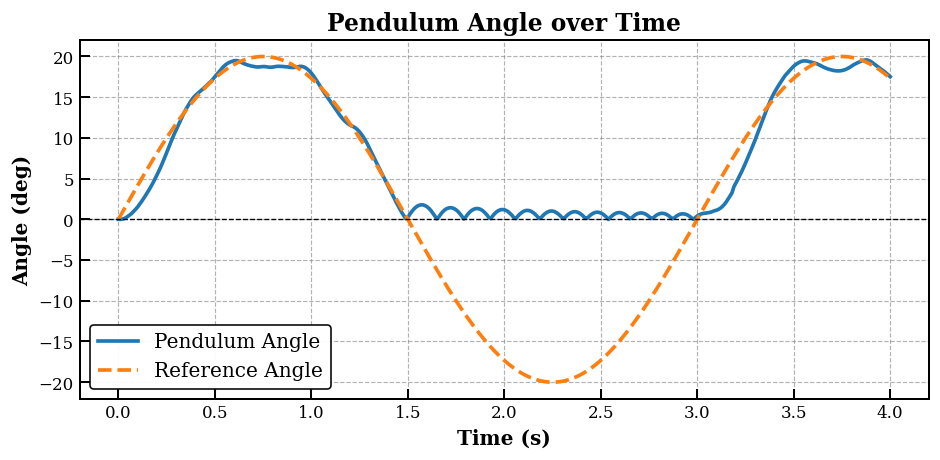

In [233]:
history = pendulum.get_history()
t_vals = history['q']['time']
q_vals = history['q']['values']

plt.figure(figsize=(8,4))
fontdict = {'fontsize': 14, 'fontweight': 'bold'}
plt.title("Pendulum Angle over Time", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals), label='Pendulum Angle')
plt.plot(t_vals_ref, np.rad2deg(q_vals_ref), label='Reference Angle', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel("Time (s)", fontweight='bold')
plt.ylabel("Angle (deg)", fontweight='bold')
plt.grid(which='both')
plt.legend()
plt.tight_layout()

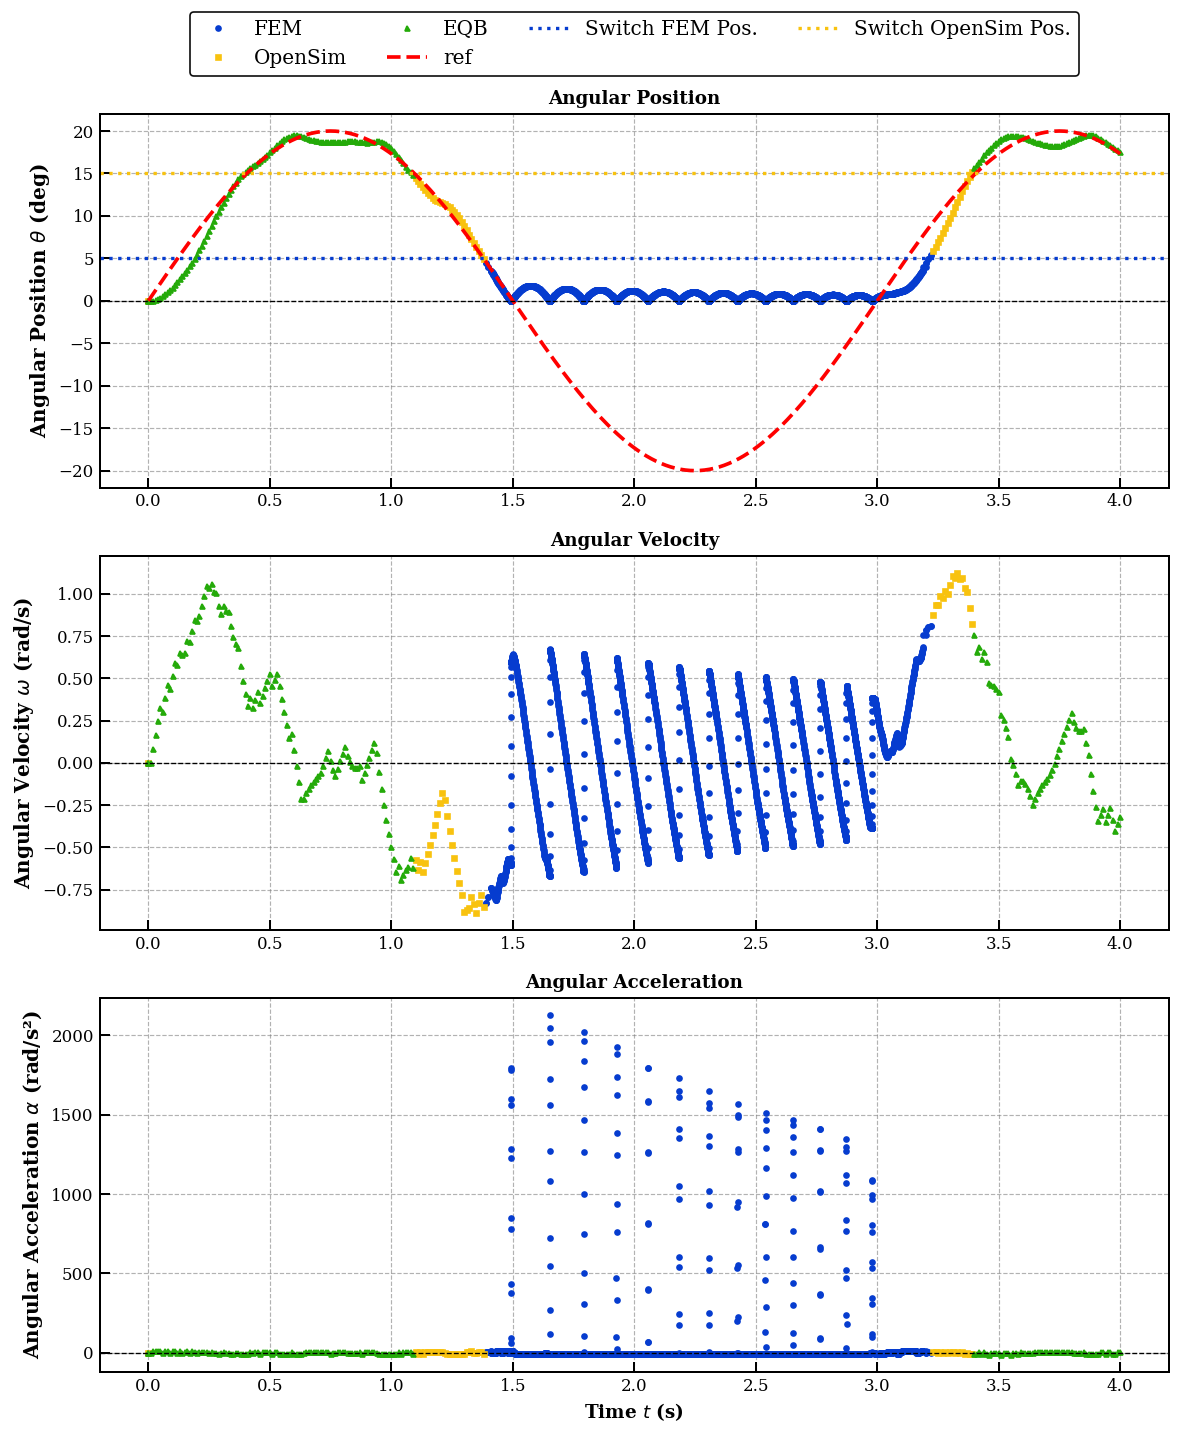

In [238]:
marker_size = 3
fem_style = {'color': "#063ccf", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  # Deep blue
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5}  # Green
eqb_style = {'color': "#24aa09", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}  # Purple
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(10, 12))

plt.subplot(3,1,1).set_title("Angular Position", **fontdict)
plt.plot(t_vals_fem, np.rad2deg(q_vals_fem), label="FEM", **fem_style)
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, np.rad2deg(q_vals_eqb), label="EQB", **eqb_style)
plt.plot(t_vals_ref, np.rad2deg(q_vals_ref), label="ref", color='red', linestyle='--')
plt.axhline(5, color=fem_style['color'], linestyle=':', label='Switch FEM Pos.', linewidth=2)
plt.axhline(15, color=opensim_style['color'], linestyle=':', label='Switch OpenSim Pos.', linewidth=2)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel(r"Angular Position $\theta$ (deg)", fontweight='bold')
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)


plt.subplot(3,1,2).set_title("Angular Velocity", **fontdict)
plt.plot(t_vals_fem, omega_vals_fem, label="FEM", **fem_style)
plt.plot(t_vals_os, omega_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, omega_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel(r"Angular Velocity $\omega$ (rad/s)", fontweight='bold')
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration", **fontdict)
plt.plot(t_vals_fem[:-1], alpha_vals_fem[:-1], label="FEM", **fem_style)
plt.plot(t_vals_os, alpha_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, alpha_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel(r"Angular Acceleration $\alpha$ (rad/s²)", fontweight='bold')
plt.grid(which='both')

plt.xlabel("Time $t$ (s)", **fontdict)
plt.tight_layout()
plt.savefig("figures/System_MasterPendulum.svg")
plt.show()

In [235]:
import tabulate
import pandas as pd

# Create DataFrame for better handling
sync_data = []

for event in pendulum.sync_events:
    # Extract values
    time = event['time']
    from_mode = event['from_mode']
    to_mode = event['to_mode']
    
    ret = event['retrieved']
    new = event['now']
    
    # Helper to extract magnitude
    def get_val(x):
        if hasattr(x, 'magnitude'):
            return x.magnitude
        return float(x) if hasattr(x, '__float__') else x
    
    sync_data.append({
        'Time (s)': f"{time:.4f}",
        'Transition': f"{from_mode} → {to_mode}",
        'θ_ret (°)': f"{np.rad2deg(get_val(ret['q']['value'])):.2f}",
        'ω_ret': f"{get_val(ret['omega']['value']):.3f}",
        'α_ret': f"{get_val(ret['alpha']['value']):.1f}",
        'τ_ret': f"{get_val(ret['torque']['value']):.2f}",
        'θ_new (°)': f"{np.rad2deg(get_val(new['q']['value'])):.2f}",
        'ω_new': f"{get_val(new['omega']['value']):.3f}",
        'α_new': f"{get_val(new['alpha']['value']):.1f}",
        'τ_new': f"{get_val(new['torque']['value']):.2f}",
    })

df = pd.DataFrame(sync_data)

print("\n" + "="*140)
print(" "*50 + "MODE SYNCHRONIZATION EVENTS")
print("="*140)
print(tabulate.tabulate(df, headers='keys', tablefmt='grid', showindex=False))
print("="*140)
print(f"Total mode switches: {len(sync_data)}")
print("="*140 + "\n")


                                                  MODE SYNCHRONIZATION EVENTS
+------------+---------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|   Time (s) | Transition    |   θ_ret (°) |   ω_ret |   α_ret |   τ_ret |   θ_new (°) |   ω_new |   α_new |   τ_new |
+============+===============+=============+=========+=========+=========+=============+=========+=========+=========+
|       1.09 | EQB → OpenSim |       14.78 |  -0.621 |     4.9 |  155.13 |       14.78 |  -0.621 |     4.9 |  155.13 |
+------------+---------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|       1.38 | OpenSim → FEM |        4.95 |  -0.851 |     3.8 |   92.91 |        4.95 |  -0.851 |     0   |   92.91 |
+------------+---------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|       3.22 | FEM → OpenSim |        5.37 |   0.809 |    -2.7 |  144.66 |        5.37 |